In [36]:
%%time
%load_ext autoreload
%autoreload 2

import pandas as pd
import wandb
import matplotlib.pyplot as plt

# Table processing
def process_line(means, highlight, highlight_index, highlight_max, ignore_std):
    if highlight:
        if highlight_max:
            tops = set(means.groupby(highlight_index).idxmax())
        else:
            tops = set(means.groupby(highlight_index).idxmin())
    else:
        tops = set()

    def process_line(x):
        if ignore_std:
            if x.name in tops:
                return rf"\textbf{{{x['mean']:0.3f}}}"
            return rf"{x['mean']:0.3f}"
        if x.name in tops:
            return rf"\textbf{{{x['mean']:0.3f} $\pm$ {x['std']:0.3f}}}"
        return rf"{x['mean']:0.3f} $\pm$ {x['std']:0.3f}"

    return process_line


def mean_pm_std(
    data,
    index,
    columns,
    value,
    highlight=True,
    highlight_cols=True,
    highlight_max=True,
    ignore_std=False,
):
    assert len(data) > 0
    groupby = data.groupby([*index, *columns])
    means = groupby.mean()[value].rename("mean")
    stds = groupby.std()[value].rename("std")
    ddf = pd.concat([means, stds], axis=1).T
    highlight_index = columns if highlight_cols else index
    ddf = ddf.apply(
        process_line(means, highlight, highlight_index, highlight_max, ignore_std)
    )
    ddf = ddf.reset_index().pivot(index=index, columns=columns)
    ddf.columns = ddf.columns.droplevel(level=0)
    return ddf

    
def flatten_dict(d, parent_key="", sep="/"):
    items = []
    for k, v in d.items():
        new_key = f"{parent_key}{sep}{k}" if parent_key else k
        if isinstance(v, dict):
            items.extend(flatten_dict(v, new_key, sep=sep).items())
        else:
            items.append((new_key, v))
    return dict(items)


def prepare_data(data):
    flattened_data = [flatten_dict(item) for item in data]
    return pd.DataFrame(flattened_data)



The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
CPU times: user 1.68 ms, sys: 0 ns, total: 1.68 ms
Wall time: 1.47 ms


In [37]:
api = wandb.Api(timeout=30)

# run_name_dict = {
#     "tarflow_up_to_4aa_v2": "TarFlow",
#     "tarflow_adaptln_up_to_4aa_v2": "TarFlow + AdaptLN/Transition",
#     "tarflow_up_to_4aa_pair_bias_small_v3": "TarFlow + Pair Bias",
#     "tarflow_up_to_4aa_backbone_v6": "TarFlow + Backbone Perm",
# }

run_names = list(run_name_dict.keys())
desired_tags = ["ablation_v2"]  # ← change or extend this list

runs = api.runs(
    "openproblems-comp/self-consume-bg",
    filters={
        "$and": [
            {"tags": {"$in": desired_tags}},
            # {"name": {"$in": run_names}},
        ]
    },
)

summary_list, config_list, name_list, tag_list = [], [], [], []
for run in runs:
    tag_list.append(run.tags)
    # .summary contains the output keys/values for metrics like accuracy.
    #  We call ._json_dict to omit large files
    summary_list.append(run.summary._json_dict)
    # .config contains the hyperparameters.
    #  We remove special values that start with _.
    config_list.append({k: v for k, v in run.config.items() if not k.startswith("_")})
    # .name is the human-readable name of the run.
    name_list.append(run.name)
df_summary = prepare_data(summary_list)
df_config = prepare_data(config_list)
tag_list = [str(t) for t in tag_list]
df = pd.concat(
    [
        pd.DataFrame(name_list, columns=["name"]),
        pd.DataFrame(tag_list, columns=["Tags"]),
        df_summary,
        df_config,
    ],
    axis=1,
)

# the three buckets you care about
group_keys = ["standard", "backbone", "pair_bias"]

# 1) carve out a new column called "group" by looking for the first matching key
df["model_type"] = df["tags"].apply(
    lambda tags: next((g for g in group_keys if g in tags), "other")
)

# 2) now you can either iterate or split by group
for name, subdf in df.groupby("model_type"):
    print(f"{name}  → {len(subdf)} runs")
    # subdf is all the runs in that bucket

# # or if you want them as separate DataFrames:
# df_standard  = df[df["group"] == "standard"]
# df_backbone  = df[df["group"] == "backbone"]
# df_pair_bias = df[df["group"] == "pair_bias"]

backbone  → 46 runs
pair_bias  → 46 runs
standard  → 46 runs


In [38]:
df

,name,Tags,_runtime,_step,_timestamp,_wandb/runtime,epoch,invert/fail_count_0.001,invert/fail_count_0.01,invert/fail_count_sample_0.001,...,callbacks/model_checkpoint_cropped/save_on_train_epoch_end,ckpt_path,task_name,model/params/total,model/params/trainable,model/params/non_trainable,model/net/perm_type,model/net/pos_embed_type,model/net/use_transition,model_type
0,faithful-durian-3176,"['ablation_v2', 'eval', 'standard', 'up_to_4aa']",1208.334543,12.0,1.746946e+09,1209,0.0,20.080000,0.00,7.92,...,None,/network/scratch/m/majdi.hassan/self-consume-b...,eval,231860832,115930416,115930416,NaN,NaN,NaN,standard
1,rare-grass-3174,"['ablation_v2', 'eval', 'standard', 'up_to_4aa']",984.324257,12.0,1.746945e+09,985,0.0,21.940001,0.00,8.64,...,None,/network/scratch/m/majdi.hassan/self-consume-b...,eval,231860832,115930416,115930416,NaN,NaN,NaN,standard
2,glowing-capybara-3175,"['ablation_v2', 'eval', 'standard', 'up_to_4aa']",937.491952,12.0,1.746945e+09,938,0.0,19.500000,0.00,7.94,...,None,/network/scratch/m/majdi.hassan/self-consume-b...,eval,231860832,115930416,115930416,NaN,NaN,NaN,standard
3,peach-sound-3179,"['ablation_v2', 'eval', 'standard', 'up_to_4aa']",599.488858,12.0,1.746946e+09,600,0.0,26.080000,0.02,10.30,...,None,/network/scratch/m/majdi.hassan/self-consume-b...,eval,231860832,115930416,115930416,NaN,NaN,NaN,standard
4,morning-breeze-3178,"['ablation_v2', 'eval', 'standard', 'up_to_4aa']",742.784688,12.0,1.746946e+09,743,0.0,29.320000,0.00,12.88,...,None,/network/scratch/m/majdi.hassan/self-consume-b...,eval,231860832,115930416,115930416,NaN,NaN,NaN,standard
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
133,tough-resonance-3461,"['ablation_v2', 'backbone', 'eval', 'up_to_4aa']",4562.098468,24.0,1.746964e+09,4563,0.0,20.360001,0.08,12.38,...,None,/network/scratch/m/majdi.hassan/self-consume-b...,eval,231860832,115930416,115930416,globloc,learned,False,backbone
134,drawn-cosmos-3462,"['ablation_v2', 'backbone', 'eval', 'up_to_4aa']",3148.722289,24.0,1.746962e+09,3149,0.0,21.180000,0.06,12.68,...,None,/network/scratch/m/majdi.hassan/self-consume-b...,eval,231860832,115930416,115930416,globloc,learned,False,backbone
135,copper-spaceship-3462,"['ablation_v2', 'backbone', 'eval', 'up_to_4aa']",3479.617533,24.0,1.746963e+09,3480,0.0,18.580000,0.06,11.38,...,None,/network/scratch/m/majdi.hassan/self-consume-b...,eval,231860832,115930416,115930416,globloc,learned,False,backbone
136,fiery-pine-3464,"['ablation_v2', 'backbone', 'eval', 'up_to_4aa']",3712.080734,24.0,1.746963e+09,3712,0.0,23.200001,0.14,13.88,...,None,/network/scratch/m/majdi.hassan/self-consume-b...,eval,231860832,115930416,115930416,globloc,learned,False,backbone


In [39]:
df["test/AAEW/proposal/energy_w2"]

0     NaN
1     NaN
2     NaN
3     NaN
4     NaN
       ..
133   NaN
134   NaN
135   NaN
136   NaN
137   NaN
Name: test/AAEW/proposal/energy_w2, Length: 138, dtype: float64

{'TFFL', 'GP', 'SLTC', 'KKQF', 'AYTG', 'KQ', 'FIGE', 'count', 'VTST', 'median', 'NY', 'ANYT', 'TD', 'AT', 'RL', 'RYDT', 'NF', 'AVEK', 'IM', 'ITQD', 'DTDL', 'SAEL', 'VLSM', 'ET', 'AWKC', 'CSGS', 'AAEW', 'FKVP', 'QADY', 'KS', 'QDED', 'HT', 'CTSA', 'LW', 'mean', 'LYVI', 'AC', 'NQFM', 'FALS', 'KG', 'RGSP', 'CSFQ', 'GN', 'DFKS', 'LPEM', 'RV', 'FIYG', 'VCVS', 'DQAL'}


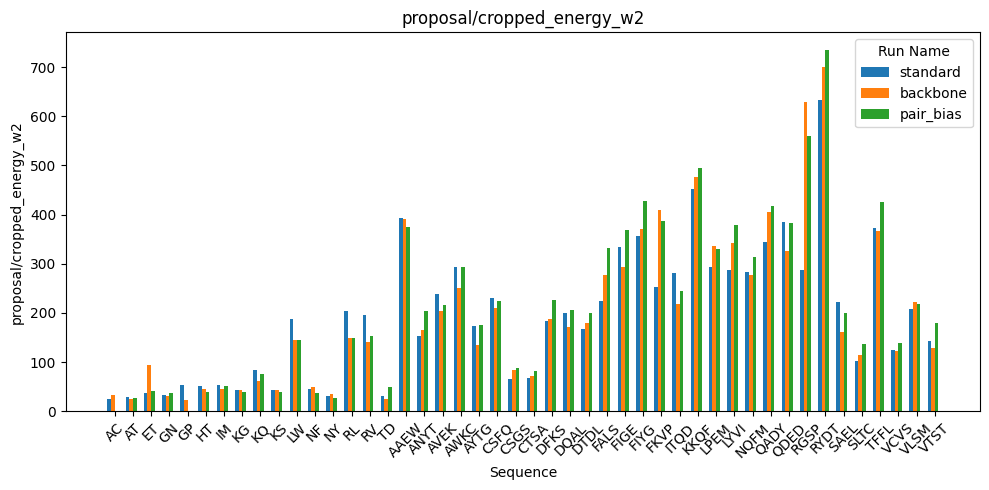

{'TFFL', 'GP', 'SLTC', 'KKQF', 'AYTG', 'KQ', 'FIGE', 'count', 'VTST', 'median', 'NY', 'ANYT', 'TD', 'AT', 'RL', 'RYDT', 'NF', 'AVEK', 'IM', 'ITQD', 'DTDL', 'SAEL', 'VLSM', 'ET', 'AWKC', 'CSGS', 'AAEW', 'FKVP', 'QADY', 'KS', 'QDED', 'HT', 'CTSA', 'LW', 'mean', 'LYVI', 'AC', 'NQFM', 'FALS', 'KG', 'RGSP', 'CSFQ', 'GN', 'DFKS', 'LPEM', 'RV', 'FIYG', 'VCVS', 'DQAL'}


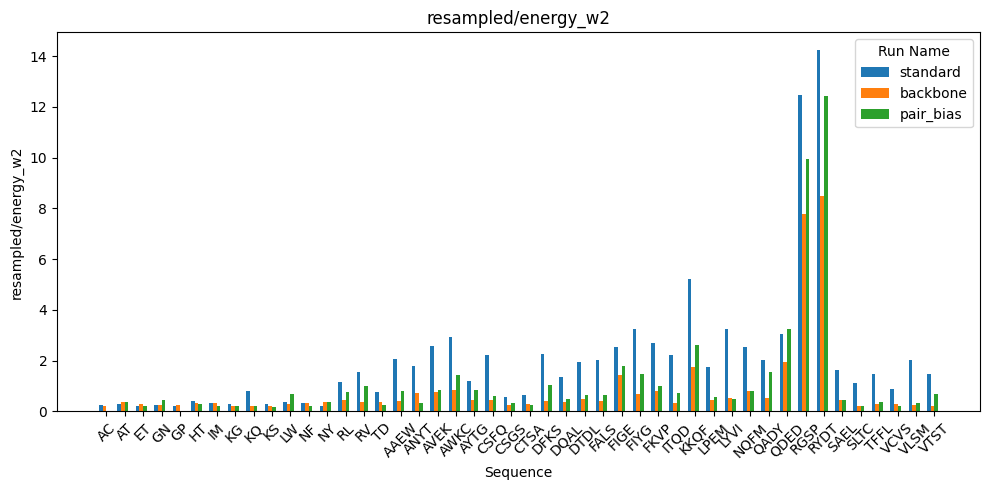

{'TFFL', 'GP', 'SLTC', 'KKQF', 'AYTG', 'KQ', 'FIGE', 'count', 'VTST', 'median', 'NY', 'ANYT', 'TD', 'AT', 'RL', 'RYDT', 'NF', 'AVEK', 'IM', 'ITQD', 'DTDL', 'SAEL', 'VLSM', 'ET', 'AWKC', 'CSGS', 'AAEW', 'FKVP', 'QADY', 'KS', 'QDED', 'HT', 'CTSA', 'LW', 'mean', 'LYVI', 'AC', 'NQFM', 'FALS', 'KG', 'RGSP', 'CSFQ', 'GN', 'DFKS', 'LPEM', 'RV', 'FIYG', 'VCVS', 'DQAL'}


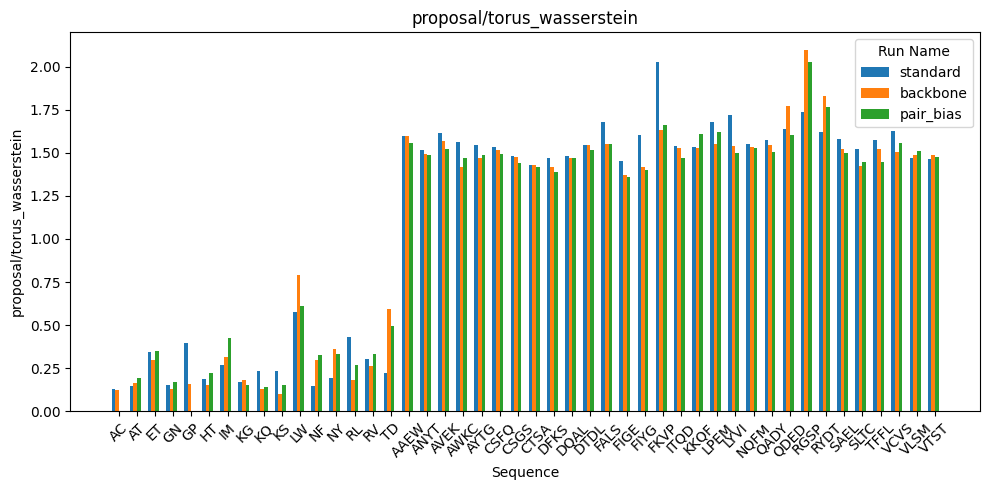

{'TFFL', 'GP', 'SLTC', 'KKQF', 'AYTG', 'KQ', 'FIGE', 'count', 'VTST', 'median', 'NY', 'ANYT', 'TD', 'AT', 'RL', 'RYDT', 'NF', 'AVEK', 'IM', 'ITQD', 'DTDL', 'SAEL', 'VLSM', 'ET', 'AWKC', 'CSGS', 'AAEW', 'FKVP', 'QADY', 'KS', 'QDED', 'HT', 'CTSA', 'LW', 'mean', 'LYVI', 'AC', 'NQFM', 'FALS', 'KG', 'RGSP', 'CSFQ', 'GN', 'DFKS', 'LPEM', 'RV', 'FIYG', 'VCVS', 'DQAL'}


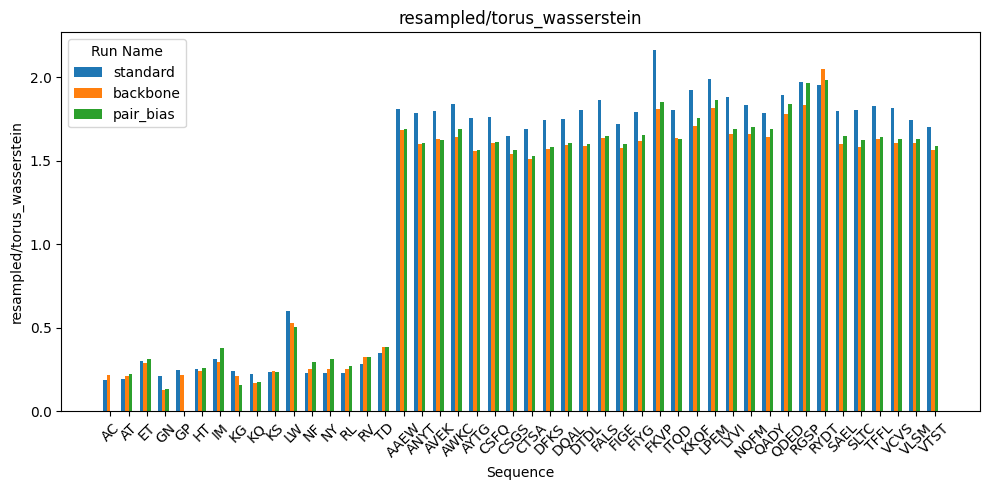

{'TFFL', 'GP', 'SLTC', 'KKQF', 'AYTG', 'KQ', 'FIGE', 'count', 'VTST', 'median', 'NY', 'ANYT', 'TD', 'AT', 'RL', 'RYDT', 'NF', 'AVEK', 'IM', 'ITQD', 'DTDL', 'SAEL', 'VLSM', 'ET', 'AWKC', 'CSGS', 'AAEW', 'FKVP', 'QADY', 'KS', 'QDED', 'HT', 'CTSA', 'LW', 'mean', 'LYVI', 'AC', 'NQFM', 'FALS', 'KG', 'RGSP', 'CSFQ', 'GN', 'DFKS', 'LPEM', 'RV', 'FIYG', 'VCVS', 'DQAL'}


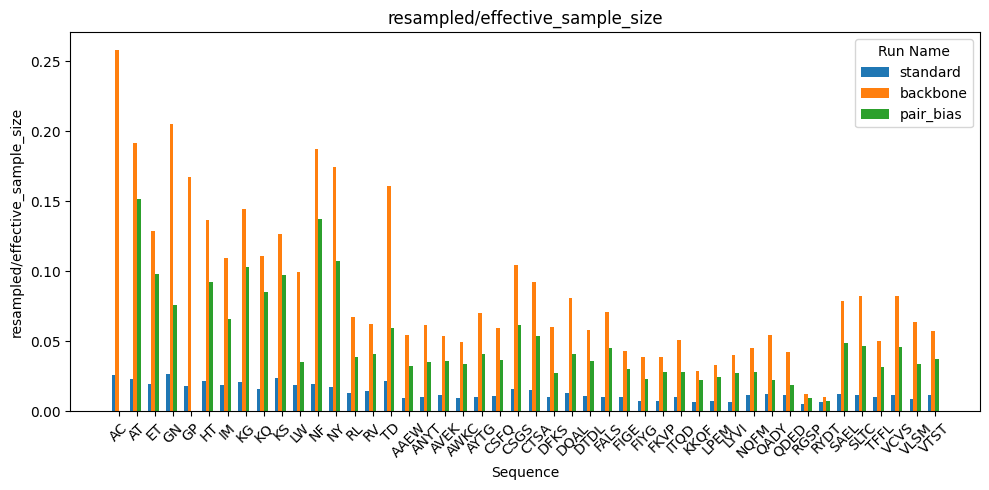

In [61]:
import matplotlib.pyplot as plt
import numpy as np

run_epoch_dict = {}

for metric in [
    "proposal/cropped_energy_w2",
    "resampled/energy_w2",
    "proposal/torus_wasserstein",
    "resampled/torus_wasserstein",
    "resampled/effective_sample_size"
]:
    prefix = "test"
    excluded_keys = {"mean", "median", "count"}
    group_keys =  ["standard", "backbone", "pair_bias"]

    # First pass: determine all seq_names (shared across runs)
    all_keys = set()
    for group in group_keys:
        run_df = df[df["model_type"] == group]
        keys = {
            col.split("/")[1]
            for col in run_df.columns
            if col.startswith(prefix) and col.endswith(metric) and len(col.split("/")) >= 4
        }
        # run_epoch_dict[run_name] = run_df["epoch"].values[0]
        all_keys.update(keys)

    print(all_keys)
    assert excluded_keys.issubset(all_keys), "Expected keys not found."
    seq_names = sorted(list(all_keys - excluded_keys), key=lambda x: (len(x), x))

    # Data structure: rows = run_names, cols = seq_names
    data = []
    for group in group_keys:
        run_df = df[df["model_type"] == group]
        # Count how many non-NaNs each row has, pick the row with the largest count
        column_names = [f"{prefix}/{seq_name}/{metric}" for seq_name in seq_names]
        metric_vals = []
        for col in column_names:
            nonnan_idx = run_df[col].notna()
            values = None
            for idx, nonnan in enumerate(nonnan_idx):
                if nonnan:
                    values     = run_df[col].iloc[idx]
                
            if values is None: 
                values = 0
            
            metric_vals.append(values)

        data.append(metric_vals)

    # Plotting
    x = np.arange(len(seq_names))  # positions for seq_names
    total_width = 0.8
    bar_width = total_width / len(run_names)

    plt.figure(figsize=(10, 5))
    for i, (group, run_values) in enumerate(zip(group_keys, data)):
        offset = (i - len(run_names) / 2) * bar_width + bar_width / 2
        plt.bar(x + offset, run_values, width=bar_width, label=f"{group}")

    plt.xticks(x, seq_names, rotation=45)
    plt.xlabel("Sequence")
    plt.ylabel(metric)
    plt.title(f"{metric}")
    plt.legend(title="Run Name")
    plt.tight_layout()
    plt.show()


In [43]:
run_df[column_names]

,test/AC/resampled/energy_w2,test/AT/resampled/energy_w2,test/ET/resampled/energy_w2,test/GN/resampled/energy_w2,test/GP/resampled/energy_w2,test/HT/resampled/energy_w2,test/IM/resampled/energy_w2,test/KG/resampled/energy_w2,test/KQ/resampled/energy_w2,test/KS/resampled/energy_w2,...,test/QADY/resampled/energy_w2,test/QDED/resampled/energy_w2,test/RGSP/resampled/energy_w2,test/RYDT/resampled/energy_w2,test/SAEL/resampled/energy_w2,test/SLTC/resampled/energy_w2,test/TFFL/resampled/energy_w2,test/VCVS/resampled/energy_w2,test/VLSM/resampled/energy_w2,test/VTST/resampled/energy_w2
35,NaN,0.356093,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
38,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
40,NaN,NaN,0.209352,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
51,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
52,NaN,NaN,NaN,0.422581,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
55,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
56,NaN,NaN,NaN,NaN,NaN,NaN,0.221441,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
57,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.171012,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
58,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.204911,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
59,NaN,NaN,NaN,NaN,NaN,0.278578,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
